In [145]:
import jax.numpy as jnp
import jax
from jaxtyping import PRNGKeyArray

from jax import Array
from jax.typing import ArrayLike
from typing import Optional

from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex

import jax_dataloader as jdl
from typing import Any, Callable, final
from typing_extensions import override

import matplotlib.pyplot as plt
import os


In [146]:
fig_dir = "/mnt/home/levans/ensemble_reweighting/parsimonious_ensembles/figures/comparing_optimizations"

In [147]:
data_directory = "/mnt/home/levans/ensemble_reweighting/parsimonious_ensembles/data/likelihoods"
log_likelihood = jnp.load(f"{data_directory}/igg/log_likelihood_cryojax.npy")

# Define diagnostics shared across methods

In [148]:
@jax.jit
def grad_log_prob(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    model = jnp.sum(likelihood*weights, axis=1)
    grad = jnp.mean(likelihood/model[:, jnp.newaxis], axis=0) 
    return grad

@jax.jit
def compute_loss(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    loss = -jnp.mean(jnp.log(jnp.sum(likelihood*weights, axis=1)))
    return loss

@jax.jit
def update_stats(weights: ArrayLike, likelihood: ArrayLike, true_weights):
    loss = compute_loss(weights, likelihood)
    #weights_error = 0.5*(jnp.sum(true_weights**2/weights) -  1)
    weights_error = jnp.sum((true_weights - weights)**2)
    posterior = (likelihood*weights)/jnp.sum(likelihood*weights, axis=1)[:, jnp.newaxis]
    ess = 1/jnp.sum(posterior**2, axis=1)
    #ess_mean = jnp.mean(ess)
    #ess_hist = jnp.hist(ess)
    return loss, weights_error, ess


In [149]:
@jax.jit
def update_weights(weights: ArrayLike, grad: ArrayLike) -> Array:
    weights = weights*grad 
    return weights

def multiplicative_gradient(
    log_likelihood: ArrayLike,
    true_weights,
    tol: Optional[float] = 1e-8,
    max_iterations: Optional[float] = 100000,
    verbose: Optional[bool]=False,
    iter_freq: Optional[int] = 100,
    weights_init=None,
    reg=0.0,
    METHOD="no_reg"
):

    num_images, num_structures = log_likelihood.shape

    # Initialize Weights
    if weights_init == None:
        weights = (1/num_structures)*jnp.ones(num_structures)

    else:
        weights = weights_init
    # Subtracting the largest entry from each row of likelihood
    # The gradient is invariant to row scaling of likelihood, so this is valid
    # With this, we avoid working in log space for the grad and loss
    log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
    
    # NOTE: we cannot exponentiate this if previous step hasn't happened 
    likelihood = jnp.exp(log_likelihood)
    
    # Iterate
    stats = {}
    stats["loss"] = []
    stats["gap"] = []
    stats["weights"] = []
    stats["weights_idx"] = []
    stats["weights_error"] = []
    stats["ess"] = []
    for k in range(max_iterations):

        # Update weights
        grad = grad_log_prob(weights, likelihood)
 
        if METHOD == "no_reg": 
            weights = update_weights(weights, grad)
        #elif METHOD == "exponentiated":
        #    weights = update_weights_exponentiated_gradient(weights, grad, reg)
        
        # update per iteration stats
        loss, weights_error, ess  = update_stats(weights, likelihood, true_weights)
        # Check stopping criterion: this `gap` is an upper bound on our loss compared to optimal weights
        gap = jnp.max(grad) - 1
        if k % iter_freq == 0: 
            if verbose:
                print(f"Number of iterations:{k}")
                print(f"Gap: {gap}") 
            stats["weights"].append(weights)
            stats["weights_idx"].append(k)
        if gap < tol:
            print(f"Number of iterations: {k}")
            print("exiting!")
            break

        stats["loss"].append(loss)
        stats["gap"].append(gap)
        stats["weights_error"].append(weights_error)
        stats["ess"].append(ess)


    stats["weights"] = jnp.stack(stats["weights"])
    stats["loss"] = jnp.stack(stats["loss"])
    stats["weights_idx"] = jnp.stack(stats["weights_idx"])
    stats["weights_error"] = jnp.stack(stats["weights_error"])
    stats["ess"] = jnp.stack(stats["ess"])
    return weights, stats


In [150]:
log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
# NOTE: we cannot exponentiate this if previous step hasn't happened 
likelihood = jnp.exp(log_likelihood)




# Define ground truth

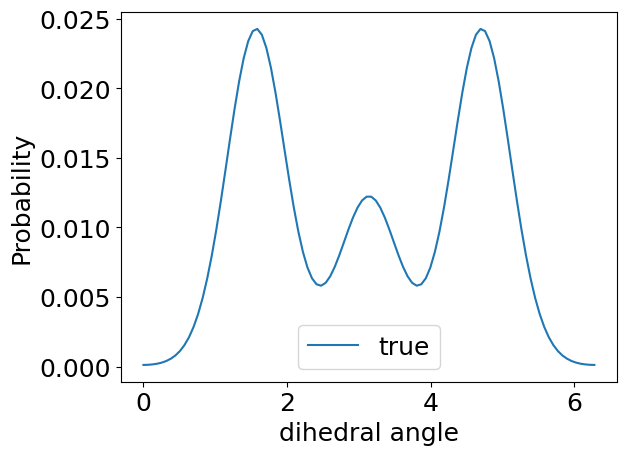

In [151]:
from scipy.stats import vonmises

## Define density that volumes are resampled from
def p(x):
    means = [jnp.pi/2, jnp.pi, 3*jnp.pi/2]
    kappas =  [6.0, 6.0, 6.0]
    weights = jnp.array([2.0, 1.0, 2.0])
    weights /= sum(weights)  
    val = 0
    for i in range(3): 
        val += weights[i]*vonmises.pdf(x, loc=means[i], kappa=kappas[i])
    return val

x = jnp.linspace(0, 2*jnp.pi, 100)
true_weights = p(x)
true_weights /= (jnp.sum(true_weights))

dx = x[1] - x[0]

# normalize output to integrate to 1 on the grid 
true_weights /= true_weights.sum() 
plt.plot(x, true_weights, label='true', color="C0")
#plt.xticks(jnp.arange(0, 20, 2))
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend()
plt.savefig(f"{fig_dir}/true_prob.png", dpi=300)
plt.show()

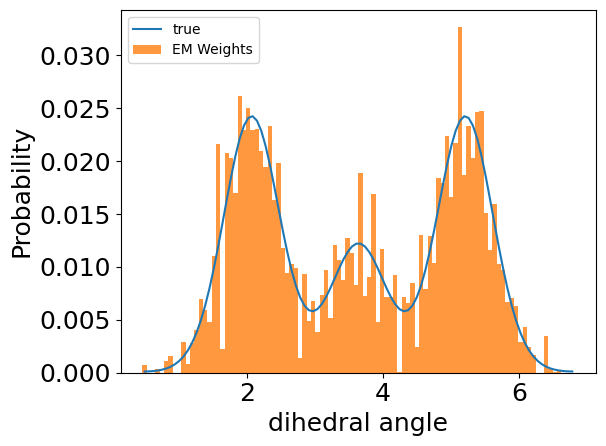

In [164]:
nodes = jnp.linspace(0, 2*jnp.pi, 100) + 0.5
results = {}

METHOD ="no_reg"
ensemble_weights, stats = multiplicative_gradient(log_likelihood, true_weights, max_iterations=10000, iter_freq=1, METHOD=METHOD)
results[METHOD] = {"ensemble_weights":ensemble_weights, "stats":stats}
plt.figure()
plt.plot(nodes, true_weights, label='true', color="C0")
plt.bar(nodes, results[METHOD]["ensemble_weights"], width=dx, label='EM Weights', color="C1", alpha=0.8)
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{fig_dir}/weight_comparison.png", dpi=300)





# Plot Some stats

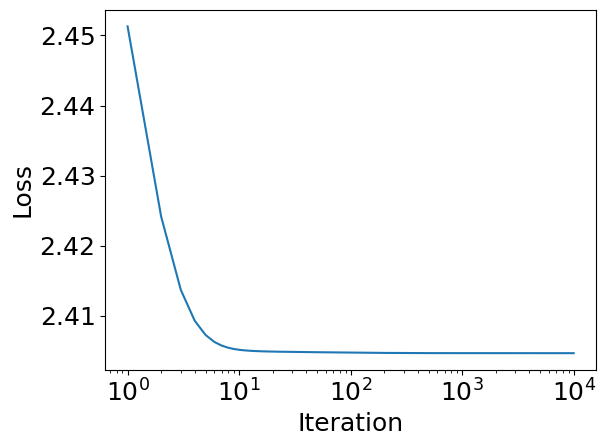

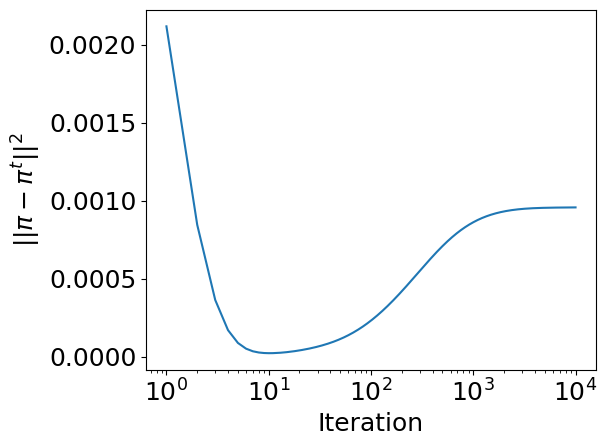

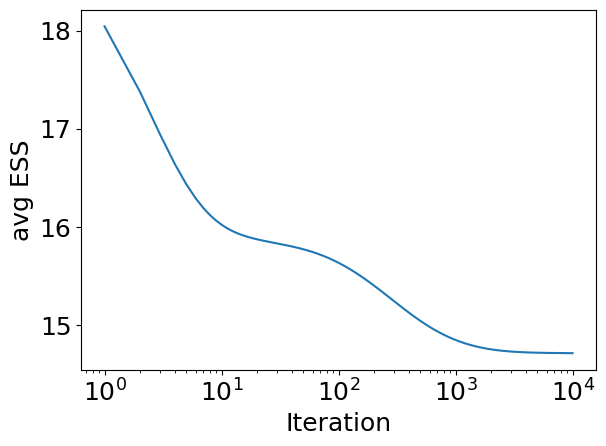

In [163]:
import numpy as np
plt.figure()
plt.rcParams.update({'font.size': 18})

check_idx = 0
METHOD = "no_reg"
losses = results[METHOD]["stats"]["loss"]

idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, losses[check_idx:])
plt.ylabel("Loss")
plt.xlabel("Iteration")
#plt.title("Loss of forward/rev. kl regularization")
plt.tight_layout()
#plt.savefig(f"{fig_dir}/losses_both_methods.png", dpi=300)
plt.savefig(f"{fig_dir}/losses.png", dpi=300)

import numpy as np
plt.figure()

check_idx = 0
METHOD = "no_reg"
losses = results[METHOD]["stats"]["weights_error"]
    
idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, losses[check_idx:])
#plt.ylabel(r"$D(\pi^* || \pi^t)$")
plt.ylabel(r"$||\pi - \pi^t||^2$")
plt.xlabel("Iteration")
#plt.title("Loss of forward/rev. kl regularization")
plt.tight_layout()
#plt.savefig(f"{fig_dir}/weights_error_both_methods.png", dpi=300)
plt.savefig(f"{fig_dir}/weights_error.png", dpi=300)

import numpy as np
plt.figure()

check_idx = 0
METHOD = "no_reg"
ess = results[METHOD]["stats"]["ess"]
ess_avg = jnp.mean(ess, axis=1)
idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, ess_avg[check_idx:])
plt.ylabel(r"avg ESS")
plt.xlabel("Iteration")
#plt.title("Loss of forward/rev. kl regularization")
plt.tight_layout()
#plt.savefig(f"{fig_dir}/weights_error_both_methods.png", dpi=300)
plt.savefig(f"{fig_dir}/avg_ess.png", dpi=300)





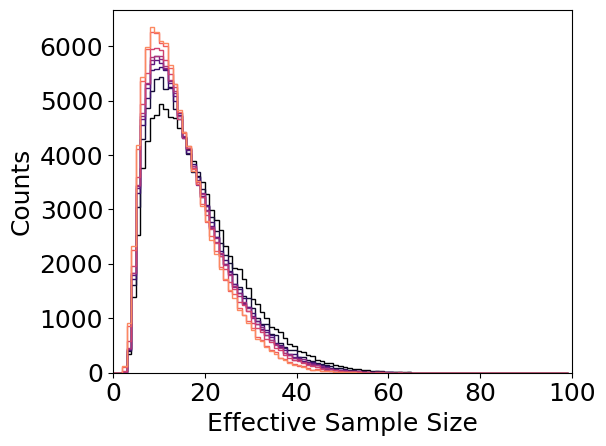

In [162]:
#cmap = plt.cm("magma")
def make_colors(num_plots):
    colors = plt.cm.magma(jnp.linspace(0,0.75,num_plots))
    return colors

idx_list = [0, 2, 4, 6, 8, 10, 100, 1000, 10000]
colors = make_colors(len(idx_list))
plt.figure()
bins = np.arange(0, 100, 1.0)
colors = make_colors(len(idx_list))
for i in range(len(idx_list)):
    METHOD = "no_reg"
    ess = results[METHOD]["stats"]["ess"][idx_list[i], :]
    plt.hist(ess, bins=bins, color=colors[i], histtype="step")
    plt.ylabel("Counts")
    plt.xlabel("Effective Sample Size")
    plt.xlim([0, 100])
plt.tight_layout()
plt.savefig(f"{fig_dir}/hist_ess.png", dpi=300)


# Save a gif

In [155]:
#import io
#from matplotlib.animation import FuncAnimation
#from PIL import Image
#import matplotlib as mpl
#
#def make_weights_figs(weights_all, weights_idx, nodes, p, dx, fig_dir):
#    #fig, ax1 = plt.subplots()
#    frames = []
#    for i in range(len(weights_idx)):
#        # Create plot
#        plt.clf()
#        _, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 10))
#        plt.subplots_adjust(wspace=0.3)
#
#        # Plot weights 
#        weights = weights_all[i, :]
#        ax1.plot(nodes, p, label='True Prob', c="C0")
#        ax1.bar(nodes, weights, width=dx,
#            label='EM Weights', alpha=0.8, color="C1")
#        ax1.text(x=3, y=0.025, s=f"iteration:{weights_idx[i]}", fontsize=20)
#        ax1.set_ylim([0, 0.03])
#        ax1.set_box_aspect(0.75)
#
#        # Plot loss
#        check_idx = 0
#        METHOD = "no_reg"
#        losses = results[METHOD]["stats"]["loss"]
#        idx = np.arange(check_idx, len(losses), 1)
#        ax2.semilogx(idx+1, losses[check_idx:])
#        ax2.scatter(i+1, losses[i], s=30, c='k')
#        ax2.set_ylabel("Loss")
#        ax2.set_box_aspect(0.75)
#        #ax2.xlabel("Iteration")
#        #plt.title("Loss of forward/rev. kl regularization")
#        #plt.tight_layout()
#        #plt.savefig(f"{fig_dir}/losses_both_methods.png", dpi=300)
#        #plt.savefig(f"{fig_dir}/losses.png", dpi=300)
#
#        losses = results[METHOD]["stats"]["weights_error"]
#        idx = np.arange(check_idx, len(losses), 1)
#        ax3.semilogx(idx+1, losses[check_idx:])
#        ax3.scatter(i+1, losses[i], s=30, c='k')
#        ax3.set_ylabel(r"$D(\pi^* || \pi^t)$")
#        ax3.set_xlabel("Iteration")
#        ax3.set_box_aspect(0.75)
#        plt.tight_layout()
#        # Save frames as images
#        buf = io.BytesIO()
#        plt.savefig(buf, format="png")
#        buf.seek(0)
#        frames.append(Image.open(buf))
#    
#        frames[0].save(
#        f"{fig_dir}/weights_path.gif",
#        save_all=True,
#        append_images=frames[1:],
#        duration=100,
#        loop=0,
#        #subrectangles=True
#    )
#
## collect all weights from one run
#weights_all = results[METHOD]["stats"]["weights"][0:100, :]
#weights_idx = results[METHOD]["stats"]["weights_idx"][0:100]
#make_weights_figs(weights_all, weights_idx, nodes, true_weights, dx, fig_dir)


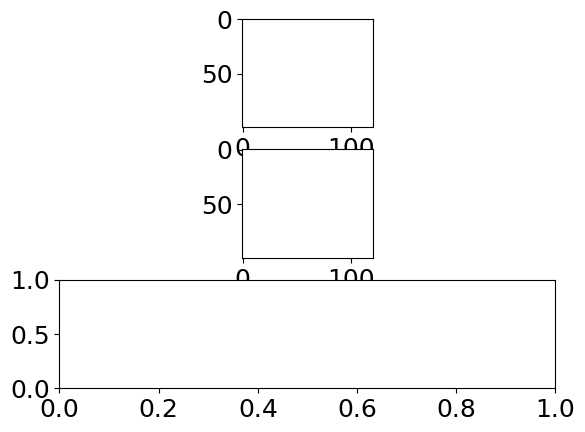

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, (ax1, ax2, ax3) = plt.subplots(3,1)


def f(x, y):
    return np.sin(x) + np.cos(y)

x = np.linspace(0, 2 * np.pi, 120)
y = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []
for i in range(60):
    x += np.pi / 15.
    y += np.pi / 20.
    im1 = ax1.imshow(f(x, y), animated=True)
    im2 = ax2.imshow(np.random.random(size=(100,120)))
    ims.append([im1,im2])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True,
                                repeat_delay=1000)

# Plot first 10 unregularized weights

KeyError: 'reverse_kl'

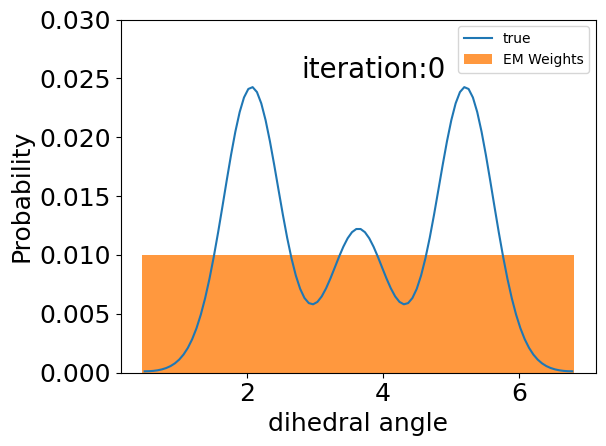

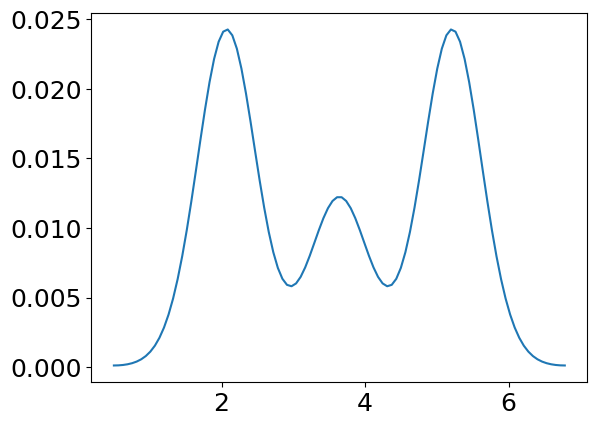

In [157]:
plt.figure() 
plt.plot(nodes, true_weights, label='true', color="C0")
plt.bar(nodes, jnp.ones_like(true_weights)/true_weights.shape[0], width=dx, label='EM Weights', color="C1", alpha=0.8)
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend(fontsize=10)
plt.ylim([0, 0.03])
plt.text(x=2.8, y=0.025, s=f"iteration:{0}", fontsize=20)
plt.tight_layout()
plt.savefig(f"{fig_dir}/weight_iter_{0}.png", dpi=300)

for i in range(10):
    plt.figure() 
    plt.plot(nodes, true_weights, label='true', color="C0")
    plt.bar(nodes, results["reverse_kl"][0]["stats"]["weights"][i+1], width=dx, label='EM Weights', color="C1", alpha=0.8)
    plt.xlabel('dihedral angle')
    plt.ylabel('Probability')  
    plt.legend(fontsize=10)
    plt.ylim([0, 0.03])
    plt.text(x=2.8, y=0.025, s=f"iteration:{i+1}", fontsize=20)
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/weight_iter_{i+1}.png", dpi=300)



Effective Sample Size Stuff